In [97]:
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from copy import deepcopy


from sklearn.inspection import permutation_importance
from sklearn.metrics import recall_score, classification_report
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Removed SMOTE import
from scipy import stats  # For statistical tests
from scipy.stats import f_oneway


import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, LSTM, Input, MultiHeadAttention,GlobalMaxPooling1D,BatchNormalization,Bidirectional,Lambda
from tensorflow.keras.layers import LayerNormalization, GlobalAveragePooling1D, Embedding
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Add
from tensorflow.keras.optimizers import Adam
from collections import Counter

import pickle

import warnings
warnings.filterwarnings('ignore')

In [98]:
# Collecting Training and Testing Dataset File Paths
dfps2019_train = []
dfps2019_test = []
labels = set()


for dirname, _, filenames in os.walk(r'E:\DACS\DACS\Data\CICDDoS2019'):

    for filename in filenames:
        if filename.endswith('-training.parquet'):
            dfp = os.path.join(dirname, filename)
            dfps2019_train.append(dfp)
            label = filename.split('-')[0]
            labels.add(label)
            print(dfp)
        elif filename.endswith('-testing.parquet'):
            dfp = os.path.join(dirname, filename)
            dfps2019_test.append(dfp)
            label = filename.split('-')[0]
            labels.add(label)
            print(dfp)

print("Các nhãn (label) tìm thấy trong CICDDos2019:")
for label in sorted(labels):
    print("-", label)


E:\DACS\DACS\Data\CICDDoS2019\DNS-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\LDAP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\LDAP-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\MSSQL-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\MSSQL-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\NetBIOS-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\NetBIOS-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\NTP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Portmap-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\SNMP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Syn-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Syn-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\TFTP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDP-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDPLag-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDPLag-training.parquet
Các nhãn (label) tìm thấy trong CICDDos2019:
- DNS
- LDAP
- MSSQL
- NTP
- NetBIOS
- Portmap
- SNMP
- Syn
- TFTP
- UDP

In [99]:
data_dir = r'E:\DACS\DACS\Data\CICDDoS2017'
labels = set()

dfps2017_train = [] 
for dirname, _, filenames in os.walk(data_dir):
    for filename in filenames:
        if filename.endswith('.parquet'):
            file_path = os.path.join(dirname, filename)
            dfps2017_train.append(file_path)
            label = filename.split('-')[0]
            labels.add(label)
            print(file_path)
print("Các nhãn (label) tìm thấy trong CICDDos2017:")
for label in sorted(labels):
    print("-", label)


E:\DACS\DACS\Data\CICDDoS2017\Benign-Monday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Botnet-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Bruteforce-Tuesday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\DDoS-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\DoS-Wednesday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Infiltration-Thursday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Portscan-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\WebAttacks-Thursday-no-metadata.parquet
Các nhãn (label) tìm thấy trong CICDDos2017:
- Benign
- Botnet
- Bruteforce
- DDoS
- DoS
- Infiltration
- Portscan
- WebAttacks


In [100]:
df_2017 = pd.concat([pd.read_parquet(dfp) for dfp in dfps2017_train], ignore_index=True)
df_2019train = pd.concat([pd.read_parquet(dfp) for dfp in dfps2019_train], ignore_index=True)
df_2019test = pd.concat([pd.read_parquet(dfp) for dfp in dfps2019_test], ignore_index=True)

df_2019_all = pd.concat([df_2019train, df_2019test], ignore_index=True)

In [101]:
print("Tổng số mẫu CICDDos2017:", len(df_2017))
print("Tổng số mẫu CICDDoS2019 train:", len(df_2019train))
print("Tổng số mẫu CICDDoS2019 test:", len(df_2019test))


print("Tổng số mẫu CICDDoS2019 (gộp train + test):", len(df_2019_all))


Tổng số mẫu CICDDos2017: 2313810
Tổng số mẫu CICDDoS2019 train: 125170
Tổng số mẫu CICDDoS2019 test: 306201
Tổng số mẫu CICDDoS2019 (gộp train + test): 431371


In [102]:
df_2017 = df_2017[df_2017['Label'].isin(['Benign', 'DDoS'])].copy()

print(df_2017['Label'].value_counts())



Label
Benign    1977318
DDoS       128014
Name: count, dtype: int64


In [103]:

ddos_labels = [
    'DrDoS_NTP', 'TFTP', 'Syn', 'UDP', 'UDP-lag', 'MSSQL', 'DrDoS_MSSQL',
    'DrDoS_DNS', 'DrDoS_SNMP', 'LDAP', 'DrDoS_LDAP', 'Portmap', 'NetBIOS',
    'DrDoS_NetBIOS', 'UDPLag', 'WebDDoS'
]

# Gán lại nhãn
df_2019_all['Label'] = df_2019_all['Label'].apply(lambda x: 'DDoS' if x in ddos_labels else x)

# Lọc lại chỉ còn Benign & DDoS
df_2019 = df_2019_all[df_2019_all['Label'].isin(['Benign', 'DDoS'])].copy()

# Xem lại kết quả
print(df_2019['Label'].value_counts())


Label
DDoS      323120
Benign     97831
Name: count, dtype: int64


In [104]:
df_all = pd.concat([df_2017, df_2019], ignore_index=True)

# In tổng số dòng dữ liệu sau khi gộp
print("Tổng số mẫu sau khi gộp:", len(df_all))
print(df_all['Label'].value_counts())

Tổng số mẫu sau khi gộp: 2526283
Label
Benign    2075149
DDoS       451134
Name: count, dtype: int64


In [105]:

df_all['is_ddos'] = df_all['Label'].apply(lambda x: 0 if x == 'Benign' else 1)

print(df_all['is_ddos'].value_counts())

is_ddos
0    2075149
1     451134
Name: count, dtype: int64


In [106]:
feature_cols = [col for col in df_all.columns if col not in ['Label', 'AttackType', 'is_ddos']]

print("Danh sách các feature dùng để train:")
print(feature_cols)
print("Tổng số feature:", len(feature_cols))

Danh sách các feature dùng để train:
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag 

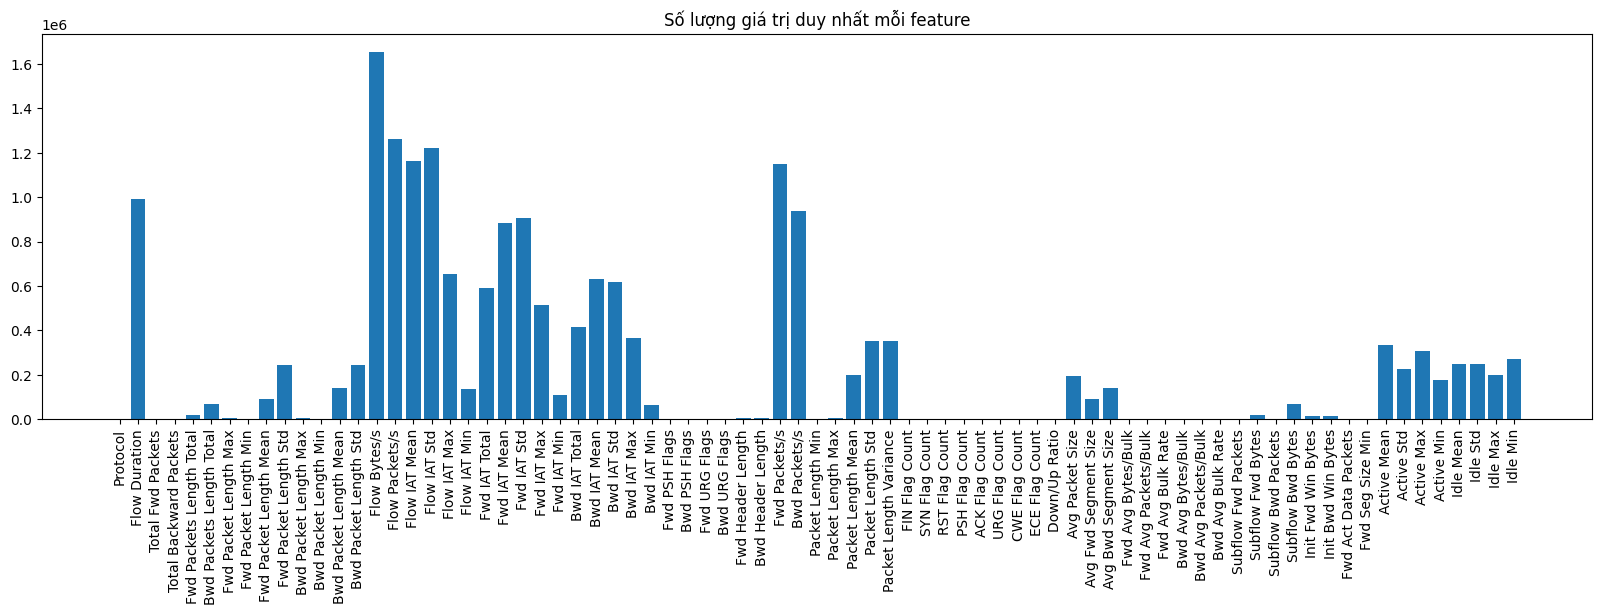

In [107]:
import matplotlib.pyplot as plt

nunique = [df_all[col].nunique() for col in feature_cols]

plt.figure(figsize=(20,5))
plt.bar(feature_cols, nunique)
plt.title('Số lượng giá trị duy nhất mỗi feature')
plt.xticks(rotation=90)
plt.show()

In [122]:
import joblib
X = df_all[feature_cols].values
y = df_all['is_ddos'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = MinMaxScaler()
scaler.fit(X_train)  # Fit scaler chỉ trên tập huấn luyện
joblib.dump(scaler, 'scaler.pkl')  # Lưu scaler để sử dụng sau này
x_train_scaled = scaler.fit_transform(X_train)      
x_test_scaled = scaler.transform(X_test) 
print(pd.Series(y_train).value_counts())

0    1660119
1     360907
Name: count, dtype: int64


In [109]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
class_weight_dict = {int(k): float(v) for k, v in class_weight_dict.items()}

print("class_weight:", class_weight_dict)

class_weight: {0: 0.6086991354234245, 1: 2.7999262968022234}


In [110]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

print("Số lượng mẫu sau khi oversampling:", Counter(y_resampled))
 

Số lượng mẫu sau khi oversampling: Counter({np.int64(0): 1660119, np.int64(1): 1660119})


In [111]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
class_weight_dict = {int(k): float(v) for k, v in class_weight_dict.items()}

print("class_weight:", class_weight_dict)

class_weight: {0: 0.6086991354234245, 1: 2.7999262968022234}


In [112]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=2, 
    min_lr=1e-6, 
    verbose=1
)

In [113]:
X_train_dl = X_resampled.reshape(-1, X_resampled.shape[1], 1)
X_test_dl = X_test.reshape(-1, X_test.shape[1], 1)


y_train_cat = to_categorical(y_resampled, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

In [114]:
def create_binary_cnn(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape, kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        Conv1D(32, kernel_size=3, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.35),
        Conv1D(48, kernel_size=3, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        GlobalMaxPooling1D(),
        Dense(48, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(0.25),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0007), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = create_binary_cnn(X_train_dl.shape[1:])
history = cnn_model.fit(
    X_train_dl, 
    y_train_cat,
    epochs=15,
    batch_size=512,
    validation_data=(X_test_dl, y_test_cat),
    class_weight=class_weight_dict,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/15
6485/6485 ━━━━━━━━━━━━━━━━━━━━ 351s 54ms/step - accuracy: 0.8130 - loss: 0.5241 - val_accuracy: 0.9361 - val_loss: 0.2383 - learning_rate: 7.0000e-04
Epoch 2/15
6485/6485 ━━━━━━━━━━━━━━━━━━━━ 341s 53ms/step - accuracy: 0.9135 - loss: 0.2545 - val_accuracy: 0.9507 - val_loss: 0.1854 - learning_rate: 7.0000e-04
Epoch 3/15
6485/6485 ━━━━━━━━━━━━━━━━━━━━ 345s 53ms/step - accuracy: 0.9314 - loss: 0.2220 - val_accuracy: 0.8948 - val_loss: 0.3367 - learning_rate: 7.0000e-04
Epoch 4/15
6485/6485 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9395 - loss: 0.2032
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.
6485/6485 ━━━━━━━━━━━━━━━━━━━━ 344s 53ms/step - accuracy: 0.9395 - loss: 0.2032 - val_accuracy: 0.9502 - val_loss: 0.2215 - learning_rate: 7.0000e-04
Epoch 5/15
6485/6485 ━━━━━━━━━━━━━━━━━━━━ 376s 58ms/step - accuracy: 0.9489 - loss: 0.1758 - val_accuracy: 0.9573 - val_loss: 0.1645 - learning_rate: 3.5000e-04
Epoch 6/15
6485/6485 ━━━━━━━━━━━━━━━━━━━━

In [71]:
def create_binary_lstm(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Conv1D(32, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        Conv1D(32, kernel_size=3, activation='relu'),
        BatchNormalization(),
        GlobalMaxPooling1D(),
        Dense(32, activation='relu'),
        Dropout(0.15),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

lstm_model = create_binary_lstm(X_train_dl.shape[1:])
history = lstm_model.fit(
    X_train_dl, 
    y_train_cat,
    epochs=15, 
    batch_size=128, 
    validation_data=(X_test_dl, y_test_cat),
    class_weight=class_weight_dict,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/15
25940/25940 ━━━━━━━━━━━━━━━━━━━━ 282s 11ms/step - accuracy: 0.8584 - loss: 0.3231 - val_accuracy: 0.8324 - val_loss: 0.4928 - learning_rate: 0.0010
Epoch 2/15
25940/25940 ━━━━━━━━━━━━━━━━━━━━ 241s 9ms/step - accuracy: 0.9404 - loss: 0.1530 - val_accuracy: 0.8283 - val_loss: 0.7269 - learning_rate: 0.0010
Epoch 3/15
25938/25940 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9520 - loss: 0.1287
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
25940/25940 ━━━━━━━━━━━━━━━━━━━━ 235s 9ms/step - accuracy: 0.9520 - loss: 0.1287 - val_accuracy: 0.8776 - val_loss: 0.6123 - learning_rate: 0.0010
Epoch 4/15
25940/25940 ━━━━━━━━━━━━━━━━━━━━ 229s 9ms/step - accuracy: 0.9615 - loss: 0.1064 - val_accuracy: 0.8265 - val_loss: 0.4617 - learning_rate: 5.0000e-04
Epoch 5/15
25940/25940 ━━━━━━━━━━━━━━━━━━━━ 231s 9ms/step - accuracy: 0.9627 - loss: 0.1037 - val_accuracy: 0.8236 - val_loss: 1.0893 - learning_rate: 5.0000e-04
Epoch 6/15
25936/25940 ━━━━━━━━━━━━━━━━━━━━ 0s

In [153]:
from tensorflow.keras.layers import Reshape

def create_transformer_model(
    num_features,
    d_model=64,
    num_heads=4,
    num_layers=2,
    dff=128,
    dropout_rate=0.1,
    num_classes=2
):

    inputs = Input(shape=(num_features,), name='input')

    x = Reshape((num_features, 1), name='reshape_to_seq')(inputs)

    x = Dense(d_model, name='linear_embedding')(x)

    for i in range(num_layers):
        attn_output = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model,
            name=f'mha_{i}'
        )(x, x, x)  # self-attention
        attn_output = Dropout(dropout_rate, name=f'dropout_attn_{i}')(attn_output)
        # Add & Norm
        out1 = LayerNormalization(epsilon=1e-6, name=f'ln_attn_{i}')(x + attn_output)

        ffn = Dense(dff, activation='relu', name=f'ffn_dense1_{i}')(out1)
        ffn = Dense(d_model, name=f'ffn_dense2_{i}')(ffn)
        ffn = Dropout(dropout_rate, name=f'dropout_ffn_{i}')(ffn)
        # Add & Norm
        x = LayerNormalization(epsilon=1e-6, name=f'ln_ffn_{i}')(out1 + ffn)

    x = GlobalAveragePooling1D(name='global_avg_pool')(x)  

    x = Dense(dff, activation='relu', name='dense_hidden')(x)
    x = Dropout(dropout_rate, name='dropout_hidden')(x)

    # 7. Output layer
    outputs = Dense(num_classes, activation='softmax', name='classifier')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Transformer_Tabular')
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


num_features = X_train_dl.shape[1]
transformer_model = create_transformer_model(
     num_features=num_features,
     d_model=64,      
     num_heads=4,
     num_layers=2,
     dff=128,
     dropout_rate=0.1,
     num_classes=2
)

transformer_model.fit(X_train_dl, y_train_cat, epochs=15, batch_size=128,
           validation_split=0.2,
           class_weight=class_weight_dict,
           callbacks=[ 
            early_stop,
            reduce_lr 
           ])

Epoch 1/15
12632/12632 ━━━━━━━━━━━━━━━━━━━━ 1488s 118ms/step - accuracy: 0.9135 - loss: 0.2123 - val_accuracy: 0.9686 - val_loss: 0.0972 - learning_rate: 0.0010
Epoch 2/15
12632/12632 ━━━━━━━━━━━━━━━━━━━━ 1308s 104ms/step - accuracy: 0.9579 - loss: 0.1123 - val_accuracy: 0.9833 - val_loss: 0.0594 - learning_rate: 0.0010
Epoch 3/15
12632/12632 ━━━━━━━━━━━━━━━━━━━━ 1512s 120ms/step - accuracy: 0.9826 - loss: 0.0579 - val_accuracy: 0.9878 - val_loss: 0.0460 - learning_rate: 0.0010
Epoch 4/15
12632/12632 ━━━━━━━━━━━━━━━━━━━━ 1222s 97ms/step - accuracy: 0.9847 - loss: 0.0518 - val_accuracy: 0.9882 - val_loss: 0.0438 - learning_rate: 0.0010
Epoch 5/15
12632/12632 ━━━━━━━━━━━━━━━━━━━━ 1219s 96ms/step - accuracy: 0.9872 - loss: 0.0453 - val_accuracy: 0.9906 - val_loss: 0.0315 - learning_rate: 0.0010
Epoch 6/15
12632/12632 ━━━━━━━━━━━━━━━━━━━━ 1228s 97ms/step - accuracy: 0.9880 - loss: 0.0427 - val_accuracy: 0.9880 - val_loss: 0.0434 - learning_rate: 0.0010
Epoch 7/15
12631/12632 ━━━━━━━━━━━━━━

In [154]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name, label_encoder=None):
    """
    Đánh giá mô hình deep learning:
      - Tự động nhận dạng nhãn test là one-hot hay số
      - In classification report, confusion matrix, recall từng lớp
      - Tính accuracy, precision, recall (weighted), F1, ROC AUC
    """
    # Nếu y_test là one-hot, lấy nhãn thật
    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        y_true = np.argmax(y_test, axis=1)
        num_classes = y_test.shape[1]
    else:
        y_true = y_test
        num_classes = len(np.unique(y_true))

    # Dự đoán xác suất
    y_pred_prob = model.predict(X_test)
    # Lấy nhãn dự đoán từ xác suất
    if y_pred_prob.shape[1] > 1:  # Softmax output
        y_pred = np.argmax(y_pred_prob, axis=1)
    else:  # Sigmoid output (nhị phân)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    # Tên lớp
    if label_encoder is not None:
        class_names = label_encoder.classes_
    else:
        class_names = [str(i) for i in range(num_classes)]

    # Đánh giá các chỉ số
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)

    # ROC AUC
    try:
        if num_classes > 2:
            roc_auc = roc_auc_score(tf.keras.utils.to_categorical(y_true), y_pred_prob, multi_class='ovr', average='weighted')
        else:
            roc_auc = roc_auc_score(y_true, y_pred_prob[:, 1] if y_pred_prob.shape[1] > 1 else y_pred_prob)
    except Exception:
        roc_auc = np.nan

    # Confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()

    # Classification report
    print(f"\nClassification Report ({model_name}):")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall_weighted:.4f}")
    print(f"F1-score (weighted): {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")

    # Recall từng lớp
    print(f"\nRecall for each class ({model_name}):")
    for i, label in enumerate(class_names):
        print(f"  {label}: {recall_per_class[i]:.4f}")


15790/15790 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step


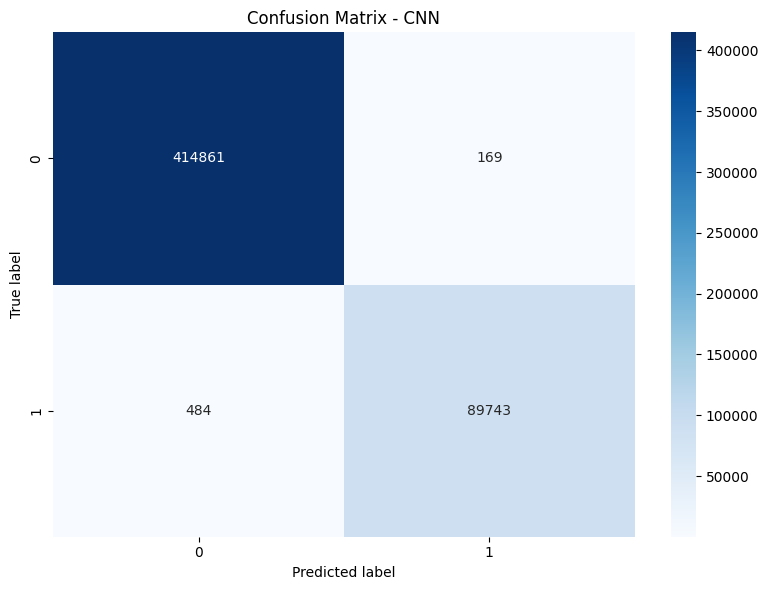


Classification Report (CNN):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    415030
           1       1.00      0.99      1.00     90227

    accuracy                           1.00    505257
   macro avg       1.00      1.00      1.00    505257
weighted avg       1.00      1.00      1.00    505257

Accuracy: 0.9987
Precision (weighted): 0.9987
Recall (weighted): 0.9987
F1-score (weighted): 0.9987
ROC AUC: 0.9999

Recall for each class (CNN):
  0: 0.9996
  1: 0.9946
15790/15790 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step


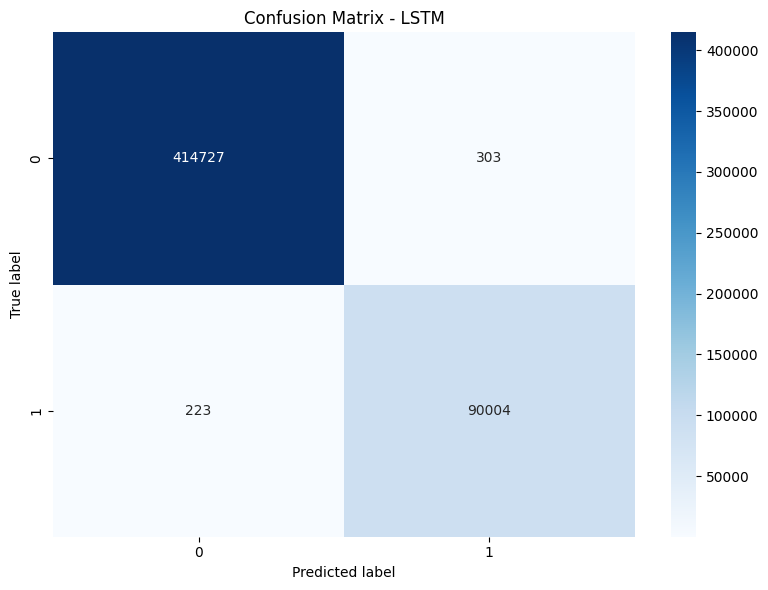


Classification Report (LSTM):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    415030
           1       1.00      1.00      1.00     90227

    accuracy                           1.00    505257
   macro avg       1.00      1.00      1.00    505257
weighted avg       1.00      1.00      1.00    505257

Accuracy: 0.9990
Precision (weighted): 0.9990
Recall (weighted): 0.9990
F1-score (weighted): 0.9990
ROC AUC: 1.0000

Recall for each class (LSTM):
  0: 0.9993
  1: 0.9975
15790/15790 ━━━━━━━━━━━━━━━━━━━━ 346s 22ms/step


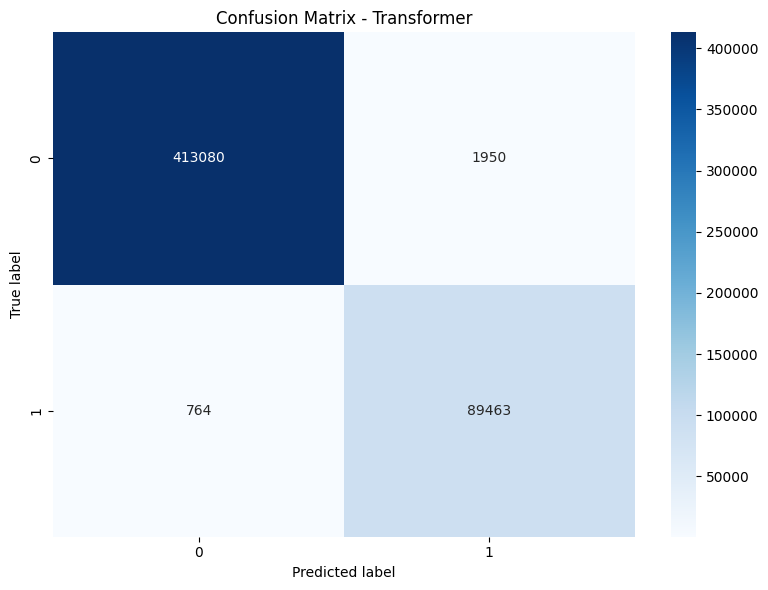


Classification Report (Transformer):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    415030
           1       0.98      0.99      0.99     90227

    accuracy                           0.99    505257
   macro avg       0.99      0.99      0.99    505257
weighted avg       0.99      0.99      0.99    505257

Accuracy: 0.9946
Precision (weighted): 0.9947
Recall (weighted): 0.9946
F1-score (weighted): 0.9946
ROC AUC: 0.9996

Recall for each class (Transformer):
  0: 0.9953
  1: 0.9915


In [155]:
evaluate_model(cnn_model, X_test_dl, y_test_cat, "CNN")
evaluate_model(lstm_model, X_test_dl, y_test_cat, "LSTM")
evaluate_model(transformer_model, X_test_dl, y_test_cat, "Transformer")

In [157]:
from tabulate import tabulate
import numpy as np

# Đánh giá lại các mô hình trên tập test
cnn_pred = np.argmax(cnn_model.predict(X_test_dl), axis=1)
lstm_pred = np.argmax(lstm_model.predict(X_test_dl), axis=1)
transformer_pred = np.argmax(transformer_model.predict(X_test_dl), axis=1)

def get_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_pred)
    }

results = {
    'CNN': get_metrics(y_test, cnn_pred),
    'LSTM': get_metrics(y_test, lstm_pred),
    'Transformer': get_metrics(y_test, transformer_pred)
}

# In bảng so sánh
headers = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']
table = []
for model, metrics in results.items():
    table.append([
        model,
        f"{metrics['accuracy']:.4f}",
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['f1']:.4f}",
        f"{metrics['roc_auc']:.4f}"
    ])
print(tabulate(table, headers=headers, tablefmt='github'))

# Chọn mô hình tốt nhất theo F1-score
best_model_name = max(results, key=lambda m: results[m]['f1'])
print(f"\nMô hình tốt nhất: {best_model_name} (F1-score: {results[best_model_name]['f1']:.4f})")

# Lưu mô hình tốt nhất
if best_model_name == 'CNN':
    cnn_model.save('CNN_ddos_model.h5')
elif best_model_name == 'LSTM':
    lstm_model.save('LSTM_ddos_model.h5')
else:
    transformer_model.save('Transformer_ddos_model.h5')
print(f"Đã lưu mô hình: {best_model_name}_ddos_model.h5")

15790/15790 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step
15790/15790 ━━━━━━━━━━━━━━━━━━━━ 49s 3ms/step
15790/15790 ━━━━━━━━━━━━━━━━━━━━ 366s 23ms/step


| Model       |   Accuracy |   Precision |   Recall |     F1 |   ROC AUC |
|-------------|------------|-------------|----------|--------|-----------|
| CNN         |     0.9987 |      0.9981 |   0.9946 | 0.9964 |    0.9971 |
| LSTM        |     0.999  |      0.9966 |   0.9975 | 0.9971 |    0.9984 |
| Transformer |     0.9946 |      0.9787 |   0.9915 | 0.9851 |    0.9934 |

Mô hình tốt nhất: LSTM (F1-score: 0.9971)
Đã lưu mô hình: LSTM_ddos_model.h5


In [73]:
# Collecting Training and Testing Dataset File Paths
df2019_train = []
dfps2019_test = []
labels = set()


for dirname, _, filenames in os.walk(r'E:\DACS\DACS\Data\CICDDoS2019'):

    for filename in filenames:
        if filename.endswith('-training.parquet'):
            dfp = os.path.join(dirname, filename)
            df2019_train.append(dfp)
            label = filename.split('-')[0]
            labels.add(label)
            print(dfp)
        elif filename.endswith('-testing.parquet'):
            dfp = os.path.join(dirname, filename)
            dfps2019_test.append(dfp)
            label = filename.split('-')[0]
            labels.add(label)
            print(dfp)

print("Các nhãn (label) tìm thấy trong CICDDos2019:")
for label in sorted(labels):
    print("-", label)

E:\DACS\DACS\Data\CICDDoS2019\DNS-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\LDAP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\LDAP-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\MSSQL-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\MSSQL-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\NetBIOS-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\NetBIOS-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\NTP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Portmap-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\SNMP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Syn-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\Syn-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\TFTP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDP-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDP-training.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDPLag-testing.parquet
E:\DACS\DACS\Data\CICDDoS2019\UDPLag-training.parquet
Các nhãn (label) tìm thấy trong CICDDos2019:
- DNS
- LDAP
- MSSQL
- NTP
- NetBIOS
- Portmap
- SNMP
- Syn
- TFTP
- UDP

In [74]:
data_dir = r'E:\DACS\DACS\Data\CICDDoS2017'
labels = set()

df2017 = [] 
for dirname, _, filenames in os.walk(data_dir):
    for filename in filenames:
        if filename.endswith('.parquet'):
            file_path = os.path.join(dirname, filename)
            df2017.append(file_path)
            label = filename.split('-')[0]
            labels.add(label)
            print(file_path)
print("Các nhãn (label) tìm thấy trong CICDDos2017:")
for label in sorted(labels):
    print("-", label)

E:\DACS\DACS\Data\CICDDoS2017\Benign-Monday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Botnet-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Bruteforce-Tuesday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\DDoS-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\DoS-Wednesday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Infiltration-Thursday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\Portscan-Friday-no-metadata.parquet
E:\DACS\DACS\Data\CICDDoS2017\WebAttacks-Thursday-no-metadata.parquet
Các nhãn (label) tìm thấy trong CICDDos2017:
- Benign
- Botnet
- Bruteforce
- DDoS
- DoS
- Infiltration
- Portscan
- WebAttacks


In [75]:
df_2017 = pd.concat([pd.read_parquet(dfp) for dfp in df2017], ignore_index=True)
df_2019 = pd.concat([pd.read_parquet(dfp) for dfp in df2019_train], ignore_index=True)

In [76]:
df = pd.concat([df_2017, df_2019], ignore_index=True)

In [77]:
features_names = [
    'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max',
    'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean',
    'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean',
    'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean',
    'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
    'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
    'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
    'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
    'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
    'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Avg Packet Size',
    'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk',
    'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate',
    'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 'Fwd Act Data Packets', 'Fwd Seg Size Min',
    'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std',
    'Idle Max', 'Idle Min'
]

In [78]:
df['AttackType'] = df['Label']

# Sau đó mới gộp nhãn Label về chỉ Benign/DDoS
def label_binary(row):
    return 'Benign' if row == 'Benign' else 'DDoS'
df['Label'] = df['Label'].apply(label_binary)

print("Label:", df['Label'].unique())
print("AttackType:", df['AttackType'].unique())

Label: ['Benign' 'DDoS']
AttackType: ['Benign' 'Bot' 'FTP-Patator' 'SSH-Patator' 'DDoS' 'DoS slowloris'
 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed' 'Infiltration'
 'PortScan' 'Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection' 'NetBIOS' 'LDAP' 'MSSQL' 'Portmap' 'Syn'
 'UDP' 'UDPLag']


In [79]:
print("Số lượng từng AttackType (trước khi gộp):")
print(df['AttackType'].value_counts())

# Nếu muốn hiện thị rõ hơn (kèm tỉ lệ %), có thể làm như sau:
total = len(df)
vc = df['AttackType'].value_counts()
for label, cnt in vc.items():
    print(f"{label:20s} | count = {cnt:6d} | {cnt/total*100:5.2f} %")



Số lượng từng AttackType (trước khi gộp):
AttackType
Benign                        2023745
DoS Hulk                       172846
DDoS                           128014
Syn                             48840
UDP                             18090
DoS GoldenEye                   10286
MSSQL                            8523
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
LDAP                             1906
Web Attack � Brute Force         1470
Bot                              1437
Portmap                           685
Web Attack � XSS                  652
NetBIOS                           644
UDPLag                             55
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
Benign               | count = 2023745 | 82.98 %
DoS Hulk             | count = 17284

In [80]:
    # Chuẩn hóa AttackType về các nhóm nhỏ hơn cho phase 2
attack_group_map = {
        # DrDoS/Reflection
        'DrDoS_DNS': 'DrDoS',
        'DrDoS_SNMP': 'DrDoS',
        'DrDoS_NTP': 'DrDoS',
        'DrDoS_MSSQL': 'DrDoS',
        'DrDoS_SSDP': 'DrDoS',
        'DrDoS_UDP': 'DrDoS',
        'TFTP': 'TFTP',
        # DDoS truyền thống
        'UDP': 'UDP',
        'UDPLag': 'UDP',
        'Syn': 'Syn',
        'MSSQL': 'MSSQL',
        'LDAP': 'LDAP',
        # DoS - đơn lẻ
        'DoS slowloris': 'DoS',
        'DoS Slowhttptest': 'DoS',
        'DoS Hulk': 'DoS',
        'DoS GoldenEye': 'DoS',
        'Heartbleed': 'Other',
        # Web
        'Web Attack � Brute Force': 'Web Attack',
        'Web Attack � XSS': 'Web Attack',
        'Web Attack � Sql Injection': 'Web Attack',
        # Brute Force & Infiltration
        'FTP-Patator': 'Brute Force',
        'SSH-Patator': 'Brute Force',
        'Infiltration': 'Other',
        'Bot': 'Other',
        # PortScan
        'PortScan': 'PortScan',
        # NetBIOS
        'NetBIOS': 'Other',
        # Other (các loại còn lại)
    }

def group_attack_type(x):
        if x == 'Benign':
            return 'Benign'
        return attack_group_map.get(x, 'Other')

df['AttackType'] = df['AttackType'].apply(group_attack_type)

print("Các nhóm attack sau khi chuẩn hóa:", df['AttackType'].unique())
print(df['AttackType'].value_counts())

Các nhóm attack sau khi chuẩn hóa: ['Benign' 'Other' 'Brute Force' 'DoS' 'PortScan' 'Web Attack' 'LDAP'
 'MSSQL' 'Syn' 'UDP']
AttackType
Benign         2023745
DoS             193745
Other           130827
Syn              48840
UDP              18145
Brute Force       9150
MSSQL             8523
Web Attack        2143
PortScan          1956
LDAP              1906
Name: count, dtype: int64


In [81]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib

# Chỉ lấy DDoS
df_attack = df[df['Label'] == 'DDoS'].copy()
X_attack = df_attack[features_names].astype(np.float32).values
y_attack = df_attack['AttackType'].values

# Encode
# 2. Encode nhãn
label_encoder = LabelEncoder()
label_encoder.fit(y_attack)
y_attack_encoded = label_encoder.fit_transform(y_attack)
joblib.dump(label_encoder, "attack_label_encoder.pkl")
n_classes = len(label_encoder.classes_)
print("Các lớp attack:", label_encoder.classes_)

X_attack_train, X_attack_test, y_attack_train, y_attack_test = train_test_split(
    X_attack, y_attack_encoded,
    test_size=0.2, random_state=42, stratify=y_attack_encoded
)

scaler = StandardScaler()
scaler.fit(X_attack_train)
joblib.dump(scaler, 'scaler_attack.pkl')
X_attack_train_scaled = scaler.transform(X_attack_train)
X_attack_test_scaled = scaler.transform(X_attack_test)

print("label_encoder.classes_:", label_encoder.classes_)


Các lớp attack: ['Brute Force' 'DoS' 'LDAP' 'MSSQL' 'Other' 'PortScan' 'Syn' 'UDP'
 'Web Attack']
label_encoder.classes_: ['Brute Force' 'DoS' 'LDAP' 'MSSQL' 'Other' 'PortScan' 'Syn' 'UDP'
 'Web Attack']


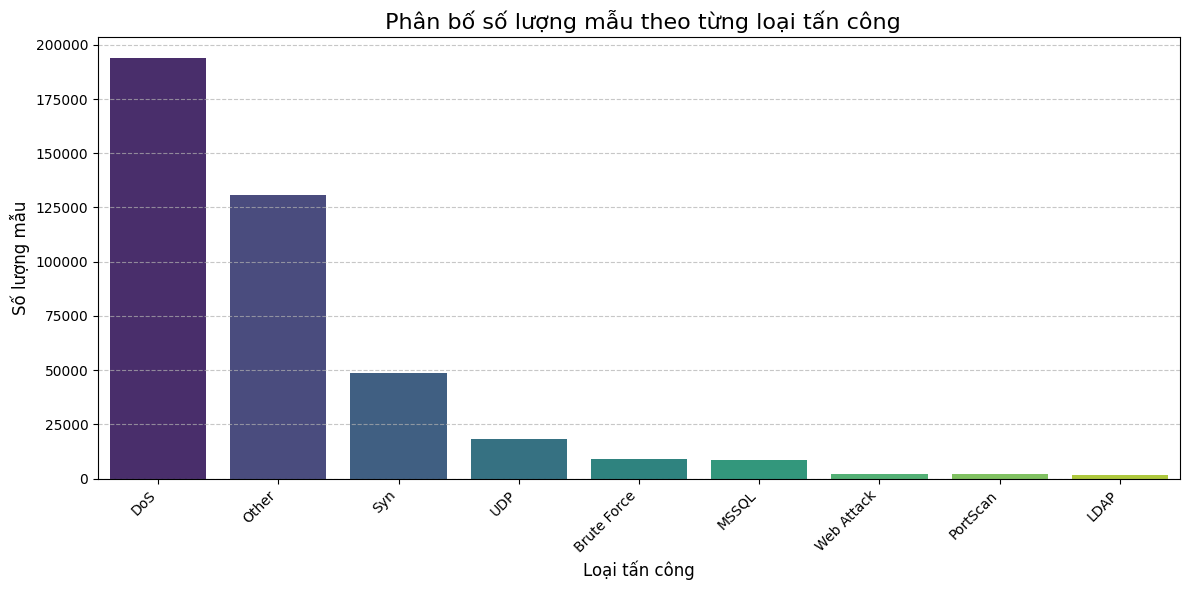

In [82]:
# Đếm số lượng mỗi lớp tấn công
attack_counts = pd.Series(y_attack).value_counts().sort_values(ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.barplot(x=attack_counts.index, y=attack_counts.values, palette="viridis")

plt.title(" Phân bố số lượng mẫu theo từng loại tấn công", fontsize=16)
plt.xlabel("Loại tấn công", fontsize=12)
plt.ylabel("Số lượng mẫu", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

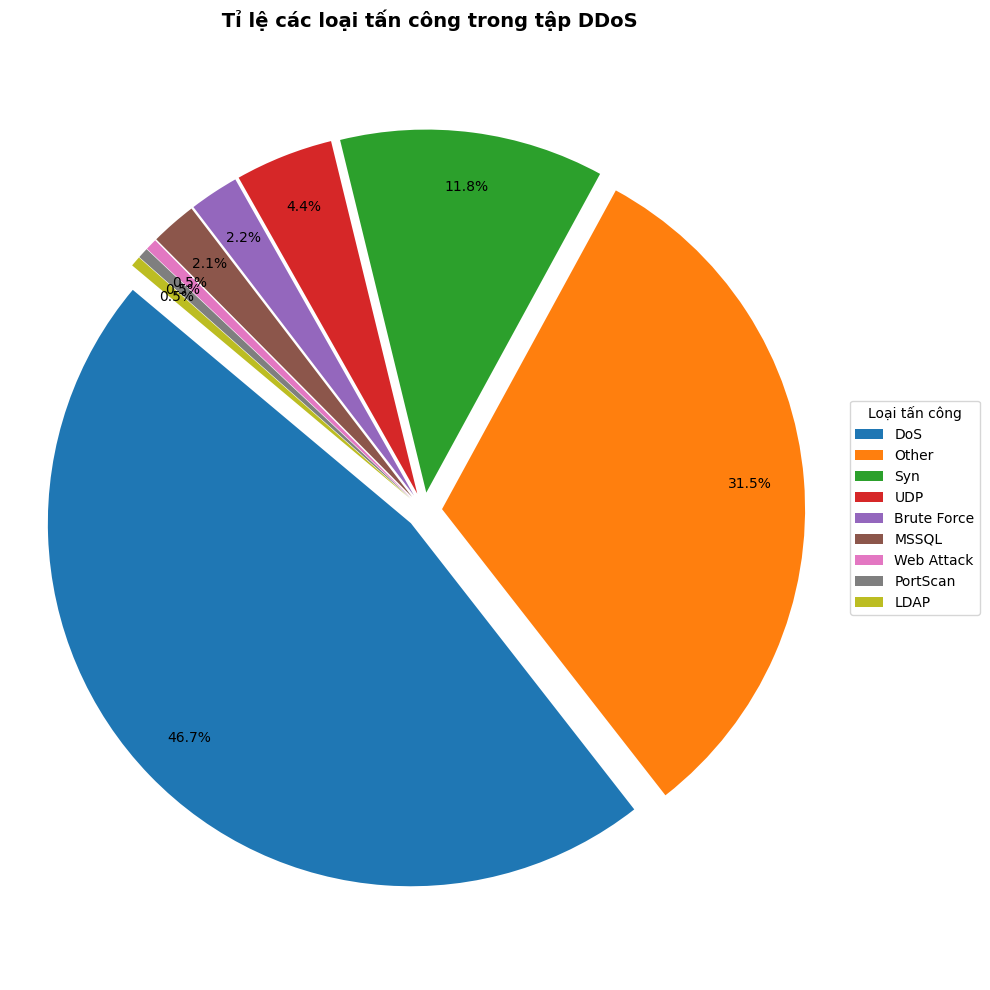

In [83]:
import matplotlib.pyplot as plt
import pandas as pd

# Phân bố attack
attack_distribution = pd.Series(y_attack).value_counts()

# Các tham số tách từng phần ra một chút để tránh đè
explode = [0.05] * len(attack_distribution)

# Vẽ Pie Chart
fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    attack_distribution.values,
    labels=None,  # Không chèn nhãn vào trong pie
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    pctdistance=0.85,       # Đẩy % ra xa hơn
    labeldistance=1.1,      # Đẩy nhãn (nếu dùng) ra ngoài
    textprops={'fontsize': 10}
)

# Chú thích ngoài
ax.legend(
    wedges,
    attack_distribution.index,
    title="Loại tấn công",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10
)

plt.title(" Tỉ lệ các loại tấn công trong tập DDoS", fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [84]:
print("Số lượng mẫu train trước khi SMOTE:", len(y_attack_train))

Số lượng mẫu train trước khi SMOTE: 332188


In [85]:
from imblearn.over_sampling import SMOTE


sm = SMOTE(random_state=42)
X_attack_train_res, y_attack_train_res = sm.fit_resample(X_attack_train  , y_attack_train)


print("Số lượng mẫu train sau khi SMOTE:", len(y_attack_train_res))

Số lượng mẫu train sau khi SMOTE: 1394964


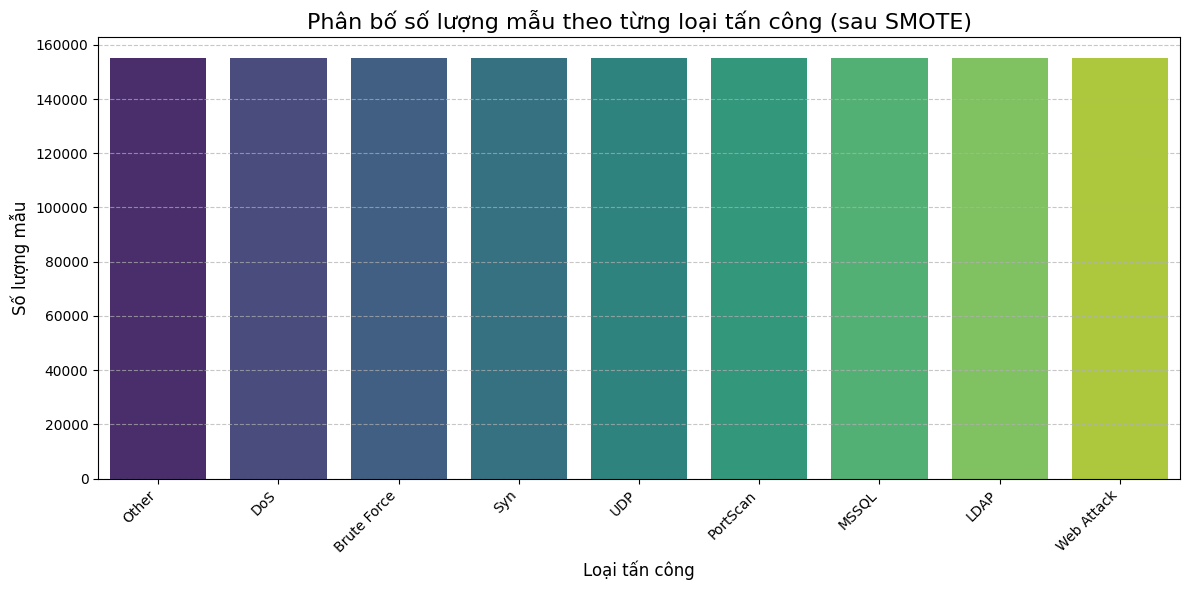

In [86]:

try:
    attack_labels_after = label_encoder.inverse_transform(y_attack_train_res)
except:
    attack_labels_after = y_attack_train_res

attack_counts_after = pd.Series(attack_labels_after).value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=attack_counts_after.index, y=attack_counts_after.values, palette="viridis")

plt.title("Phân bố số lượng mẫu theo từng loại tấn công (sau SMOTE)", fontsize=16)
plt.xlabel("Loại tấn công", fontsize=12)
plt.ylabel("Số lượng mẫu", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [87]:
######### cÓ SMOTE #######

X_attack_train_res_scaled = scaler.transform(X_attack_train_res)


y_attack_train_cat = to_categorical(y_attack_train_res, num_classes=n_classes)


y_attack_test_cat = to_categorical(y_attack_test, num_classes=n_classes)


X_attack_train_scaled_cnn = X_attack_train_res_scaled.reshape(-1, len(features_names), 1)
X_attack_test_scaled_cnn = X_attack_test_scaled.reshape(-1, len(features_names), 1)

In [88]:
######## kHÔNG SMOTE ########


X_attack_train_scaled_no = X_attack_train_scaled.reshape(-1, len(features_names), 1)
X_attack_test_scaled_no  = X_attack_test_scaled.reshape(-1, len(features_names), 1)


y_attack_train_cat_no = to_categorical(y_attack_train, num_classes=n_classes)
y_attack_test_cat_no  = to_categorical(y_attack_test,  num_classes=n_classes)

In [89]:
from sklearn.utils import class_weight

idx_ldap = np.where(label_encoder.classes_ == 'LDAP')[0][0]
idx_mssql = np.where(label_encoder.classes_ == 'MSSQL')[0][0]

class_weights_manual = {i: 1.0 for i in range(n_classes)}
class_weights_manual[idx_ldap] = 15.0
class_weights_manual[idx_mssql] = 20.0


In [ ]:

from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, Bidirectional, LSTM, Dense
from tensorflow.keras.regularizers import l2

# Custom Attention Layer cho 1D sequence
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight', shape=(input_shape[-1], 1),
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='att_bias', shape=(input_shape[1], 1),
                                 initializer='zeros', trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

def create_cnn_bilstm_attention(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(128, kernel_size=5, activation='relu', kernel_regularizer=l2(1e-4))(inputs)
    x = BatchNormalization()(x)
    x = Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Conv1D(32, kernel_size=3, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(x)
    attn = AttentionLayer()(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(attn)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.0002),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [91]:
# Huấn luyện trên tập train đã SMOTE, chuẩn hóa và reshape
model = create_cnn_bilstm_attention(X_attack_train_scaled_cnn.shape[1:], n_classes)

history = model.fit(
    X_attack_train_scaled_cnn, y_attack_train_cat,
    epochs=5,
    batch_size=16,
    validation_data=(X_attack_test_scaled_cnn, y_attack_test_cat),
    class_weight=class_weights_manual,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

# Lưu model
model.save('attack_classifier.h5')


Epoch 1/5
10667/87186 ━━━━━━━━━━━━━━━━━━━━ 1:34:14 74ms/step - accuracy: 0.6965 - loss: 1.8657

KeyboardInterrupt: 

In [ ]:
model = create_cnn_bilstm_attention(X_attack_train_scaled_no.shape[1:], n_classes)

history = model.fit(
    X_attack_train_scaled_no, y_attack_train_cat_no,
    epochs=5,
    batch_size=32,
    validation_data=(X_attack_test_scaled_cnn, y_attack_test_cat),
    class_weight=class_weights_manual,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

Epoch 1/5
20762/20762 ━━━━━━━━━━━━━━━━━━━━ 1793s 86ms/step - accuracy: 0.8979 - loss: 0.4790 - val_accuracy: 0.9747 - val_loss: 0.1002 - learning_rate: 2.0000e-04
Epoch 2/5
20762/20762 ━━━━━━━━━━━━━━━━━━━━ 1706s 82ms/step - accuracy: 0.9799 - loss: 0.1647 - val_accuracy: 0.9632 - val_loss: 0.1976 - learning_rate: 2.0000e-04
Epoch 3/5
20762/20762 ━━━━━━━━━━━━━━━━━━━━ 1716s 83ms/step - accuracy: 0.9894 - loss: 0.1324 - val_accuracy: 0.9909 - val_loss: 0.0553 - learning_rate: 2.0000e-04
Epoch 4/5
20762/20762 ━━━━━━━━━━━━━━━━━━━━ 1807s 87ms/step - accuracy: 0.9915 - loss: 0.1131 - val_accuracy: 0.5550 - val_loss: 2.3336 - learning_rate: 2.0000e-04
Epoch 5/5
20762/20762 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9913 - loss: 0.1087
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.
20762/20762 ━━━━━━━━━━━━━━━━━━━━ 2002s 96ms/step - accuracy: 0.9913 - loss: 0.1087 - val_accuracy: 0.8974 - val_loss: 0.3469 - learning_rate: 2.0000e-04
Restoring model weights from 

In [94]:
model.save('attack_classifier.h5')

2596/2596 ━━━━━━━━━━━━━━━━━━━━ 105s 40ms/step


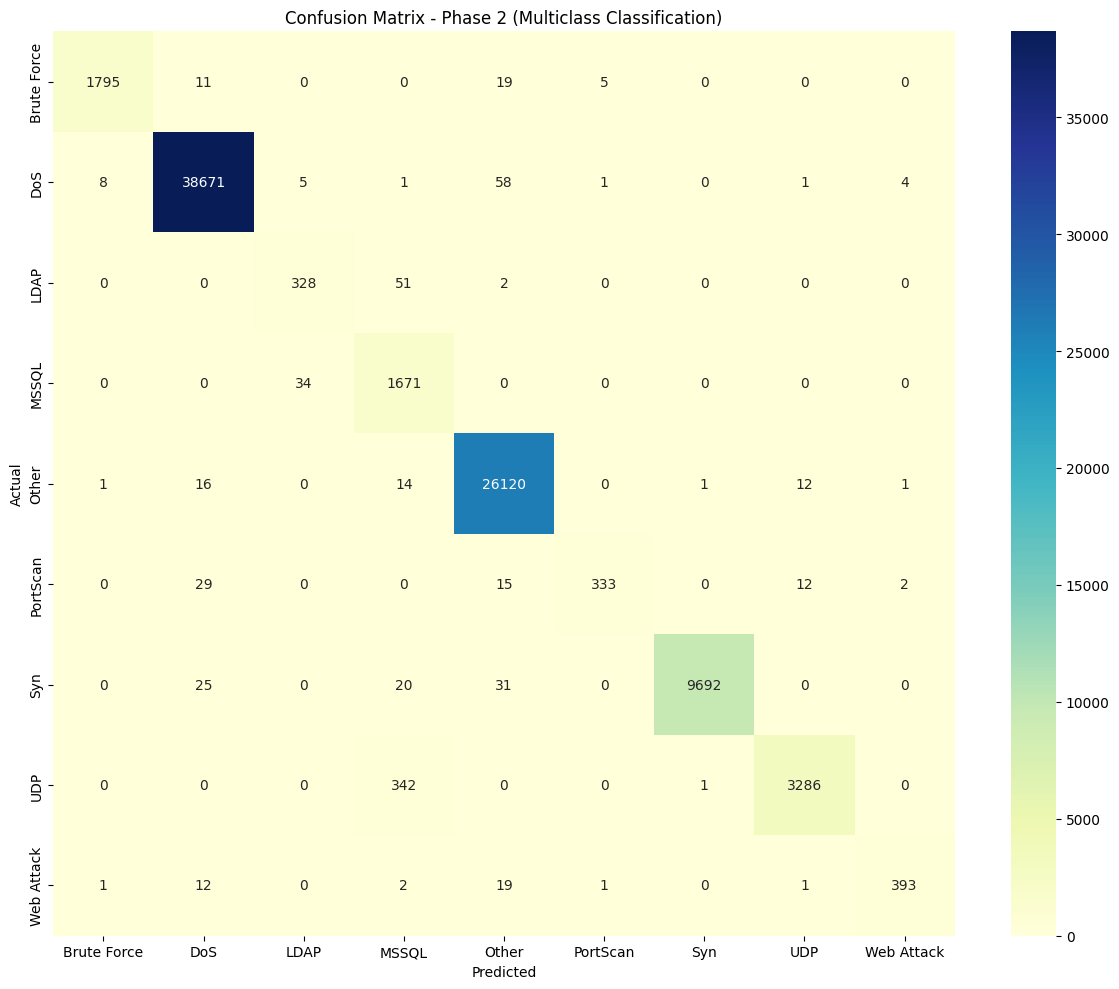

              precision    recall  f1-score   support

 Brute Force       0.99      0.98      0.99      1830
         DoS       1.00      1.00      1.00     38749
        LDAP       0.89      0.86      0.88       381
       MSSQL       0.80      0.98      0.88      1705
       Other       0.99      1.00      1.00     26165
    PortScan       0.98      0.85      0.91       391
         Syn       1.00      0.99      1.00      9768
         UDP       0.99      0.91      0.95      3629
  Web Attack       0.98      0.92      0.95       429

    accuracy                           0.99     83047
   macro avg       0.96      0.94      0.95     83047
weighted avg       0.99      0.99      0.99     83047



In [93]:
y_attack_test_labels = label_encoder.inverse_transform(y_attack_test)

# Dự đoán lại trên toàn bộ attack samples
y_attack_test_pred_prob = model.predict(X_attack_test_scaled_no)
y_attack_test_pred = np.argmax(y_attack_test_pred_prob, axis=1)

labels_multi = label_encoder.classes_
cm_multi = confusion_matrix(y_attack_test, y_attack_test_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=labels_multi, yticklabels=labels_multi)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Phase 2 (Multiclass Classification)")
plt.tight_layout()
plt.show()

print(classification_report(y_attack_test, y_attack_test_pred, target_names=labels_multi))